  Review_ID  Word_Count  Exclamation_Marks  Question_Marks  Uppercase_Words  \
0   REV0001         112                  7               2                6   
1   REV0002         445                  0               2               19   
2   REV0003         358                  8               4                4   
3   REV0004         280                  5               4                0   
4   REV0005         116                  6               0               16   

   Avg_Word_Length  Unique_Words_Ratio  Negative_Words_Count  \
0             6.76                0.65                     3   
1             6.31                0.42                     2   
2             5.67                0.78                    12   
3             5.31                0.99                     0   
4             4.39                0.82                     2   

   Positive_Words_Count  Sentiment_Score Sentiment  
0                     3            -0.26   Neutral  
1                     7           

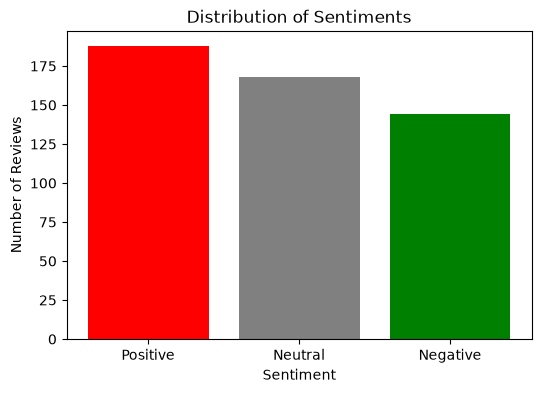

Sentiment
Positive    37.6
Neutral     33.6
Negative    28.8
Name: proportion, dtype: float64


Word_Count              261.000
Exclamation_Marks         4.000
Question_Marks            2.000
Uppercase_Words          10.000
Avg_Word_Length           5.005
Unique_Words_Ratio        0.640
Negative_Words_Count      7.000
Positive_Words_Count      9.000
Sentiment_Score           0.060
dtype: float64

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)


df = pd.read_excel("sentiment_analysis (1).xlsx")
print(df.head())
df.tail()
print("Rows and Columns:", df.shape)
print(df.columns)
df.dtypes
df.info()
df.isnull().sum()
(df.isnull().sum()/len(df))*100
print("Duplicate rows :", df.duplicated().sum())
df= df.drop_duplicates()
df.describe(include="all")
df["Sentiment"].value_counts()
sentiment_count = df["Sentiment"].value_counts()

print(sentiment_count)

sentiment_count = df["Sentiment"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(sentiment_count.index, sentiment_count.values, color=["red","gray","green"])

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

percentage = df["Sentiment"].value_counts(normalize=True) * 100

print(percentage)

df.describe()
#calculate mean
df.mean(numeric_only=True)
df.median(numeric_only=True)


In [25]:
df.median(numeric_only=True)

Word_Count              261.000
Exclamation_Marks         4.000
Question_Marks            2.000
Uppercase_Words          10.000
Avg_Word_Length           5.005
Unique_Words_Ratio        0.640
Negative_Words_Count      7.000
Positive_Words_Count      9.000
Sentiment_Score           0.060
dtype: float64

In [26]:
df.std(numeric_only=True)

Word_Count              139.434861
Exclamation_Marks         2.982285
Question_Marks            1.425049
Uppercase_Words           5.755019
Avg_Word_Length           1.119644
Unique_Words_Ratio        0.206263
Negative_Words_Count      4.315276
Positive_Words_Count      5.913064
Sentiment_Score           0.559359
dtype: float64

In [32]:
summery=pd.DataFrame({"Mean": df.mean(numeric_only=True),
                    "Median": df.median(numeric_only=True),
                    "Standard Deviation": df.std(numeric_only=True)})
print(summery.round(2))

                        Mean  Median  Standard Deviation
Word_Count            259.89  261.00              139.43
Exclamation_Marks       4.54    4.00                2.98
Question_Marks          1.96    2.00                1.43
Uppercase_Words         9.50   10.00                5.76
Avg_Word_Length         4.97    5.00                1.12
Unique_Words_Ratio      0.65    0.64                0.21
Negative_Words_Count    6.81    7.00                4.32
Positive_Words_Count    9.64    9.00                5.91
Sentiment_Score         0.05    0.06                0.56


In [33]:
num = df.select_dtypes(include=['number'])

In [34]:
corr = num.corr()

print(corr)

                      Word_Count  Exclamation_Marks  Question_Marks  \
Word_Count              1.000000          -0.063039       -0.007917   
Exclamation_Marks      -0.063039           1.000000       -0.032651   
Question_Marks         -0.007917          -0.032651        1.000000   
Uppercase_Words         0.033817           0.097205       -0.022236   
Avg_Word_Length        -0.030470           0.008225        0.051411   
Unique_Words_Ratio     -0.048609           0.054419        0.018666   
Negative_Words_Count   -0.004088          -0.049585        0.029821   
Positive_Words_Count    0.016491           0.020974        0.046262   
Sentiment_Score         0.031621          -0.018850        0.040101   

                      Uppercase_Words  Avg_Word_Length  Unique_Words_Ratio  \
Word_Count                   0.033817        -0.030470           -0.048609   
Exclamation_Marks            0.097205         0.008225            0.054419   
Question_Marks              -0.022236         0.051411 

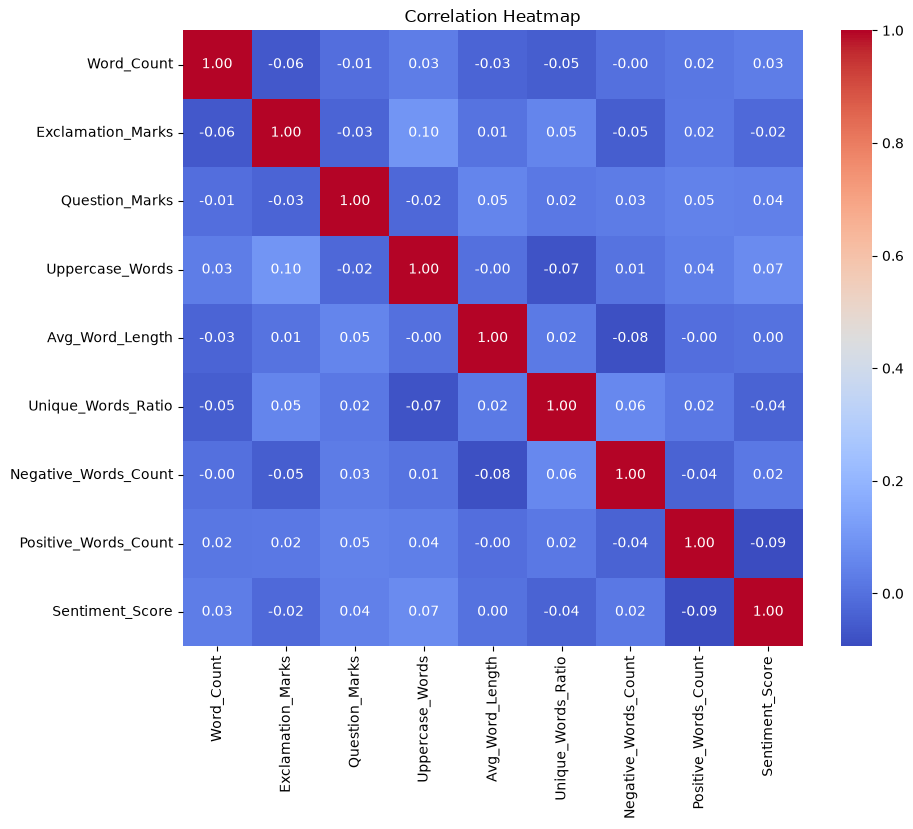

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [36]:
corr["Sentiment_Score"].sort_values(ascending=False)

Sentiment_Score         1.000000
Uppercase_Words         0.070934
Question_Marks          0.040101
Word_Count              0.031621
Negative_Words_Count    0.020361
Avg_Word_Length         0.003744
Exclamation_Marks      -0.018850
Unique_Words_Ratio     -0.035033
Positive_Words_Count   -0.093970
Name: Sentiment_Score, dtype: float64

In [37]:
corr["Sentiment_Score"].drop("Sentiment_Score").sort_values(ascending=False)

Uppercase_Words         0.070934
Question_Marks          0.040101
Word_Count              0.031621
Negative_Words_Count    0.020361
Avg_Word_Length         0.003744
Exclamation_Marks      -0.018850
Unique_Words_Ratio     -0.035033
Positive_Words_Count   -0.093970
Name: Sentiment_Score, dtype: float64

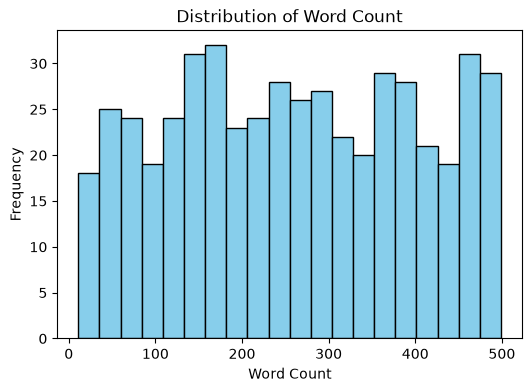

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["Word_Count"], bins=20, color="skyblue", edgecolor="black")

plt.title("Distribution of Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.show()

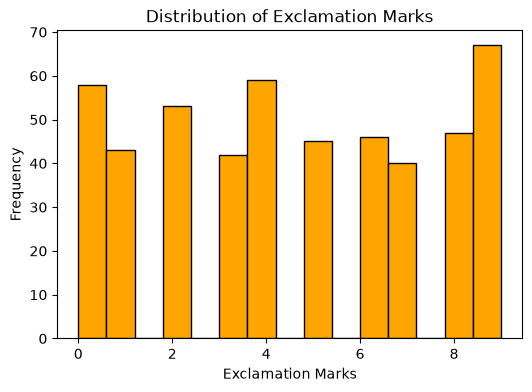

In [39]:
plt.figure(figsize=(6,4))
plt.hist(df["Exclamation_Marks"], bins=15, color="orange", edgecolor="black")

plt.title("Distribution of Exclamation Marks")
plt.xlabel("Exclamation Marks")
plt.ylabel("Frequency")

plt.show()

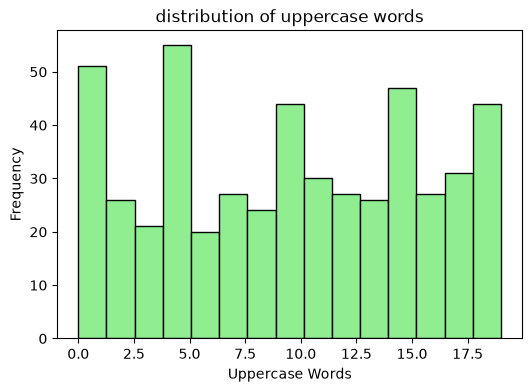

In [42]:
plt.figure(figsize=(6,4))
plt.hist(df["Uppercase_Words"],bins=15,color="lightgreen",edgecolor="black")
plt.title("distribution of uppercase words")
plt.xlabel("Uppercase Words")
plt.ylabel("Frequency")
plt.show()

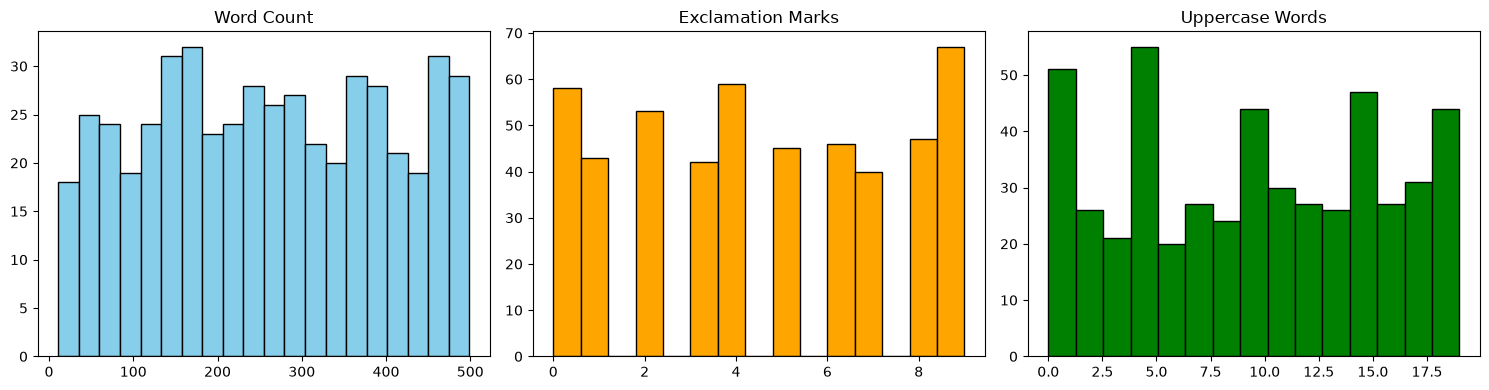

In [43]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(df["Word_Count"], bins=20, color="skyblue", edgecolor="black")
plt.title("Word Count")

plt.subplot(1,3,2)
plt.hist(df["Exclamation_Marks"], bins=15, color="orange", edgecolor="black")
plt.title("Exclamation Marks")

plt.subplot(1,3,3)
plt.hist(df["Uppercase_Words"], bins=15, color="green", edgecolor="black")
plt.title("Uppercase Words")

plt.tight_layout()
plt.show()

In [44]:
avg_features = df.groupby("Sentiment").mean(numeric_only=True)

print(avg_features)

           Word_Count  Exclamation_Marks  Question_Marks  Uppercase_Words  \
Sentiment                                                                   
Negative   263.743056           4.590278        1.854167         8.965278   
Neutral    252.666667           4.392857        1.958333         9.738095   
Positive   263.398936           4.638298        2.053191         9.696809   

           Avg_Word_Length  Unique_Words_Ratio  Negative_Words_Count  \
Sentiment                                                              
Negative          4.901042            0.661111              6.548611   
Neutral           5.020417            0.649583              7.166667   
Positive          4.967713            0.635638              6.680851   

           Positive_Words_Count  Sentiment_Score  
Sentiment                                         
Negative              10.229167        -0.651806  
Neutral                9.666667        -0.008750  
Positive               9.164894         0.644574 

In [45]:
avg_features.round(2)

,Word_Count,Exclamation_Marks,Question_Marks,Uppercase_Words,Avg_Word_Length,Unique_Words_Ratio,Negative_Words_Count,Positive_Words_Count,Sentiment_Score
Sentiment,,,,,,,,,
Negative,263.74,4.59,1.85,8.97,4.90,0.66,6.55,10.23,-0.65
Neutral,252.67,4.39,1.96,9.74,5.02,0.65,7.17,9.67,-0.01
Positive,263.40,4.64,2.05,9.70,4.97,0.64,6.68,9.16,0.64


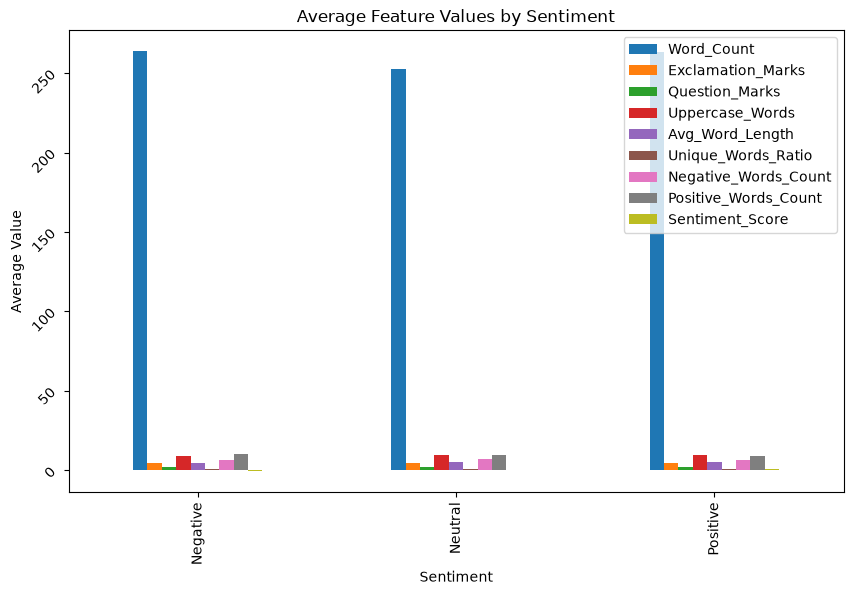

In [48]:
import matplotlib.pyplot as plt

avg_features.plot(kind="bar", figsize=(10,6))

plt.title("Average Feature Values by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Value")
plt.yticks(rotation=45)

plt.show()

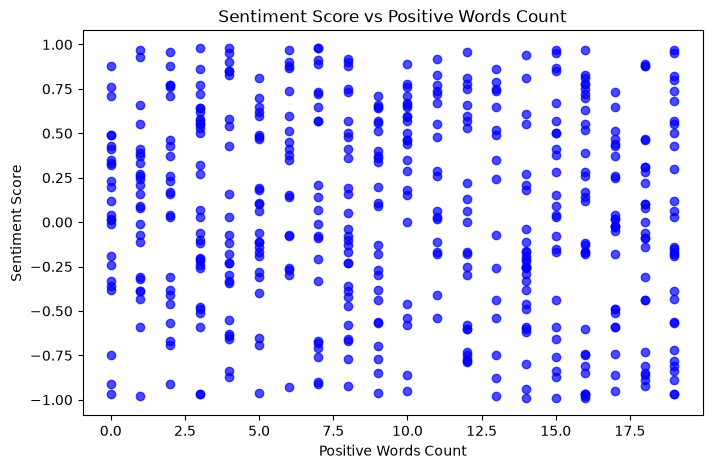

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["Positive_Words_Count"],
            df["Sentiment_Score"],
            color="blue",
            alpha=0.7)

plt.title("Sentiment Score vs Positive Words Count")
plt.xlabel("Positive Words Count")
plt.ylabel("Sentiment Score")

plt.show()

In [50]:
correlation = df["Positive_Words_Count"].corr(df["Sentiment_Score"])

print("Correlation:", correlation)

Correlation: -0.09397046465429419


In [51]:
Q1 = df["Exclamation_Marks"].quantile(0.25)
Q3 = df["Exclamation_Marks"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[df["Exclamation_Marks"] > upper]

print(outliers)

Empty DataFrame
Columns: [Review_ID, Word_Count, Exclamation_Marks, Question_Marks, Uppercase_Words, Avg_Word_Length, Unique_Words_Ratio, Negative_Words_Count, Positive_Words_Count, Sentiment_Score, Sentiment]
Index: []


In [52]:
Q1 = df["Negative_Words_Count"].quantile(0.25)
Q3 = df["Negative_Words_Count"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[df["Negative_Words_Count"] > upper]

print(outliers)

Empty DataFrame
Columns: [Review_ID, Word_Count, Exclamation_Marks, Question_Marks, Uppercase_Words, Avg_Word_Length, Unique_Words_Ratio, Negative_Words_Count, Positive_Words_Count, Sentiment_Score, Sentiment]
Index: []


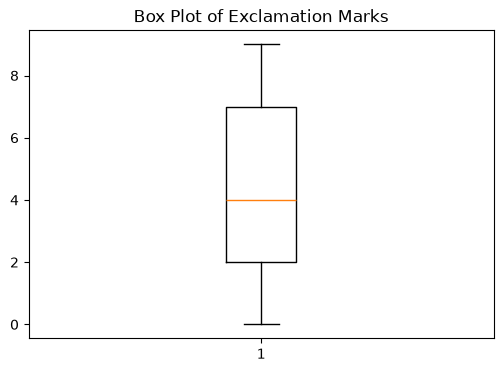

In [2]:
# matplotlib.pyplot is already imported in CELL INDEX 0
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))

plt.boxplot(df["Exclamation_Marks"])

plt.title("Box Plot of Exclamation Marks")

plt.show()

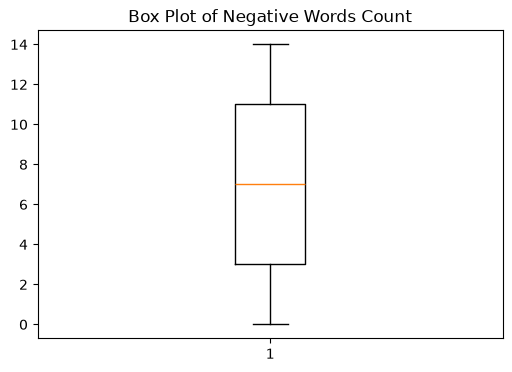

In [3]:
plt.figure(figsize=(6,4))

plt.boxplot(df["Negative_Words_Count"])

plt.title("Box Plot of Negative Words Count")

plt.show()

In [7]:
group_mean = df.groupby("Sentiment").mean(numeric_only=True).round(2)

print(group_mean)

           Word_Count  Exclamation_Marks  Question_Marks  Uppercase_Words  \
Sentiment                                                                   
Negative       263.74               4.59            1.85             8.97   
Neutral        252.67               4.39            1.96             9.74   
Positive       263.40               4.64            2.05             9.70   

           Avg_Word_Length  Unique_Words_Ratio  Negative_Words_Count  \
Sentiment                                                              
Negative              4.90                0.66                  6.55   
Neutral               5.02                0.65                  7.17   
Positive              4.97                0.64                  6.68   

           Positive_Words_Count  Sentiment_Score  
Sentiment                                         
Negative                  10.23            -0.65  
Neutral                    9.67            -0.01  
Positive                   9.16             0.64 

In [8]:
# Most common sentiment
most_common = df["Sentiment"].value_counts().idxmax()

print("Most Common Sentiment:", most_common)

Most Common Sentiment: Positive


In [9]:
avg_score = df["Sentiment_Score"].mean()

print("Average Sentiment Score:", round(avg_score,2))

Average Sentiment Score: 0.05


In [10]:
print("Average Positive Words:",
      round(df["Positive_Words_Count"].mean(),2))

print("Average Negative Words:",
      round(df["Negative_Words_Count"].mean(),2))

Average Positive Words: 9.64
Average Negative Words: 6.81


In [11]:
corr = df.corr(numeric_only=True)

print(corr["Sentiment_Score"].sort_values(ascending=False))

Sentiment_Score         1.000000
Uppercase_Words         0.070934
Question_Marks          0.040101
Word_Count              0.031621
Negative_Words_Count    0.020361
Avg_Word_Length         0.003744
Exclamation_Marks      -0.018850
Unique_Words_Ratio     -0.035033
Positive_Words_Count   -0.093970
Name: Sentiment_Score, dtype: float64


In [12]:
print("========== BUSINESS INSIGHTS ==========")

print("1. Most customer reviews are:", most_common)

print("2. Average Sentiment Score:",
      round(avg_score,2))

print("3. Average Positive Words:",
      round(df["Positive_Words_Count"].mean(),2))

print("4. Average Negative Words:",
      round(df["Negative_Words_Count"].mean(),2))

print("5. Customers with more positive words generally have higher sentiment scores.")

print("6. Reviews with many negative words should be analyzed for customer complaints.")

print("7. Outlier reviews require special attention from the support team.")

========== BUSINESS INSIGHTS ==========
1. Most customer reviews are: Positive
2. Average Sentiment Score: 0.05
3. Average Positive Words: 9.64
4. Average Negative Words: 6.81
5. Customers with more positive words generally have higher sentiment scores.
6. Reviews with many negative words should be analyzed for customer complaints.
7. Outlier reviews require special attention from the support team.
